In [220]:
import sys
sys.path.append('C:/myProjects/phenomobile')

import importlib
import itertools
from pathlib import Path
import os
import pandas as pd
import h5py
import ast
import numpy as np

pd.set_option('display.max_columns', None)

# NDI tables

In [ ]:

df_name='Anthocyanin_with_hs_051225-050226_clean'
h5_file='ndi_tables_for_hyper_sp_imgs_dataset_20251201_20260204.h5'

root_dir="c:/myProjects/phenomobile"
df_path=f'{root_dir}/datasets/BneiAtarot'

df=pd.read_csv(f"{df_path}/{df_name}.csv")

ndi_tables_dir = Path("c:/myProjects/phenomobile/ndi_tables")
ndi_tables_dir.mkdir(parents=True, exist_ok=True)
h5_output_dir = ndi_tables_dir 

h5_path =f'{h5_output_dir}/{h5_file}'
print(h5_path)

c:\myProjects\phenomobile\ndi_tables/ndi_tables_for_hyper_sp_imgs_dataset_20251201_20260204.h5


In [306]:
df.head(1)

,img_num,label_name,longitude,latitude,acquisition date,FVC,ndvi_mean,ndvi_std,ndvi_median,gndvi_mean,evi_mean,lai_mean,table_key,category,Lettuce color,Leaf sample weight (mg),Sample disc weight (g),Anthocyanins OD-530 nm,Chlorophyll OD-657 nm,Chlorophyll interference,Anthocyanin,DATE,Illumination
0,160,R1,34.916241,32.025185,01-12-2025,0.085995,0.843834,0.049662,0.855091,0.843834,0.983351,3.439766,table_0_1774168017329665568,RED_white_blue_led_ids,RED,0.22,0.03,0.7162,0.107,0.027,0.689,2025-12-05,White+Blue LED


In [300]:
import src.ml.training
import src.ml.train_on_ndi_tables

importlib.reload(src.ml.train_on_ndi_tables)
importlib.reload(src.ml.training)

from src.ml.train_on_ndi_tables import  TrainOnNdiTables   

In [317]:
# Initialize training
task="regression"
dataset_path=f"{df_path}/{df_name}.csv"
H5_FILE_PATH=h5_path
target='Anthocyanin'

ml =TrainOnNdiTables (
    dataset_name=dataset_path,
    target=target,
    config=None,
    task=task,
    model=None,
    logger=None,
    H5_FILE_PATH=H5_FILE_PATH
)


In [318]:
ml.compute_r2_score_for_ndi_cube()

best_wl1, best_wl2, best_r2 = ml.get_best_ndi_combination_r2()
print(f"Best combination: {best_wl1} and {best_wl2} with R² = {best_r2:.4f}")

Best combination: 577.96 and 580.90 with R² = 0.6788


In [309]:
ml.compute_rmse_score_for_ndi_cube()
best_wl1, best_wl2, best_rmse = ml.get_best_ndi_combination_rmse()
print(f"Best NDI combination: {best_wl1} and {best_wl2} with RMSE: {best_rmse}")


Best NDI combination: 577.96 and 580.90 with RMSE: 0.2300218131836914


In [320]:
ndi_cube, y_values, _ =ml.get_X_and_y()

In [321]:


# Current shape: (310, 204, 204)
n_samples = ndi_cube.shape[0]

# Flatten the last two dimensions
# Resulting shape: (310, 41616)
X_pls = ndi_cube.reshape(n_samples, -1)

print(f"New shape for PLS: {X_pls.shape}")

New shape for PLS: (308, 41616)


In [322]:
# Get indices for the upper triangle (excluding the diagonal)
# k=1 means we start one step above the diagonal
triu_indices = np.triu_indices(n=204, k=1)

# Extract only the unique pairs for all 310 samples
# Resulting shape: (310, 20706)
X_pls_unique = ndi_cube[:, triu_indices[0], triu_indices[1]]

print(f"Optimized shape for PLS: {X_pls_unique.shape}")

Optimized shape for PLS: (308, 20706)


In [287]:
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.model_selection import RepeatedKFold,LeaveOneOut
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

In [323]:
print(min(y_values))
print(max(y_values))


0.033
1.576


In [324]:


# Initialize PLS (e.g., with 10 components)
pls = PLSRegression(n_components=20)

# Fit the model using your merged target from the CLI command
pls.fit(X_pls_unique, y_values)

# Predict
y_pred = pls.predict(X_pls_unique)

# Calculate metrics
r2 = r2_score(y_values, y_pred)
rmse = np.sqrt(mean_squared_error(y_values, y_pred))

print(f"R²: {r2}")
print(f"RMSE: {rmse}")

R²: 0.8969089419346774
RMSE: 0.12663874056141708


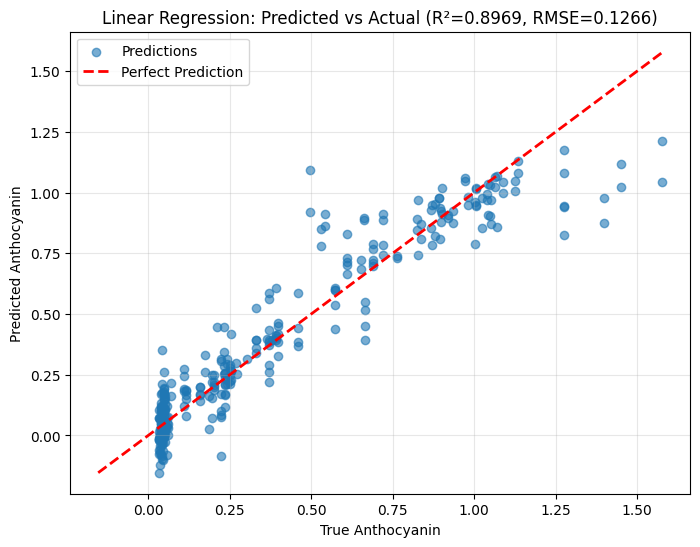

In [325]:
# show prediction vs actual

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_values, y_pred, alpha=0.6, label='Predictions')

# Add perfect prediction line
min_val = min(y_values.min(), y_pred.min())
max_val = max(y_values.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', 
        label='Perfect Prediction', linewidth=2)

# Formatting
plt.xlabel(f'True {target}')
plt.ylabel(f'Predicted {target}')
plt.title(f'Linear Regression: Predicted vs Actual (R²={r2:.4f}, RMSE={rmse:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

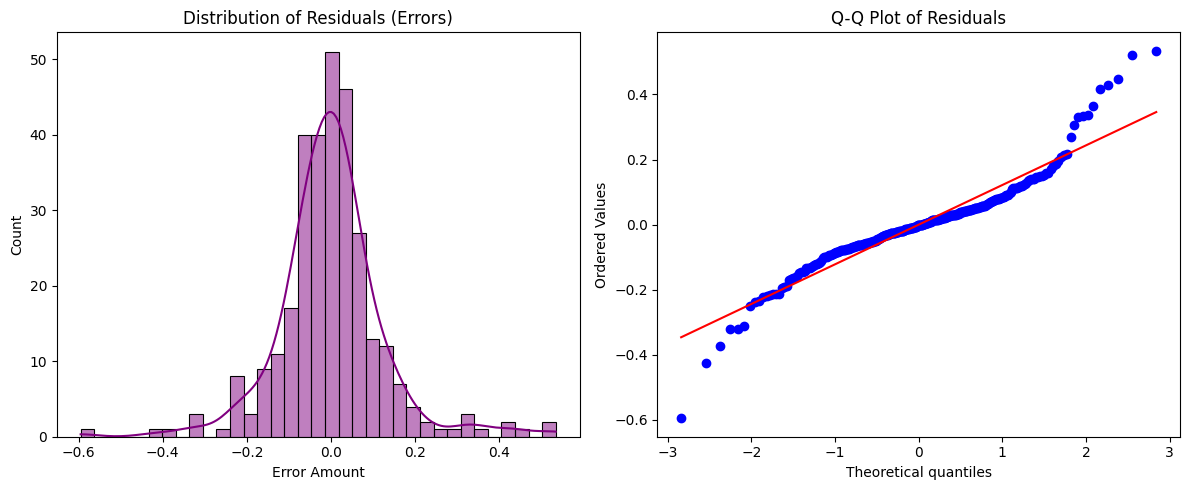

Model RMSE: 0.1266
Mean of Residuals: -0.0000


In [326]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.metrics import mean_squared_error

# 1. Calculate Residuals
# Assuming y_values are your actual lab results and 
# preds are the results from cross_val_predict
residuals = y_values - y_pred

# 2. Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# --- LEFT PLOT: Residual Histogram ---
# We want to see a 'Bell Curve' shape here
sns.histplot(residuals, kde=True, ax=ax[0], color='purple')
ax[0].set_title('Distribution of Residuals (Errors)')
ax[0].set_xlabel('Error Amount')

# --- RIGHT PLOT: Q-Q Plot ---
# This is the standard way to verify normality
stats.probplot(residuals, dist="norm", plot=ax[1])
ax[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

# 3. Print basic error stats
rmse = np.sqrt(mean_squared_error(y_values, y_pred))
print(f"Model RMSE: {rmse:.4f}")
print(f"Mean of Residuals: {np.mean(residuals):.4f}") # Should be very close to 0

In [293]:
cv_strat = KFold(n_splits=5, shuffle=True, random_state=42)
n_parallel = -1 # Use all cores for K-Fold

max_comp = 25
test_range = np.arange(1, max_comp +1)
rmse_cv = []

for n in test_range:
    pls = PLSRegression(n_components=n)
    try:
        preds = cross_val_predict(pls, X_pls_unique, y_values, cv=cv_strat, n_jobs=-1)
        rmse_cv.append(np.sqrt(mean_squared_error(y_values, preds)))
    except:
        rmse_cv.append(np.inf)
        
rmse_cv = np.array(rmse_cv)

In [294]:
components= test_range
best_idx = np.argmin(rmse_cv)
best_n = components[best_idx]
print(f"Best n_components: {best_n}")

Best n_components: 19


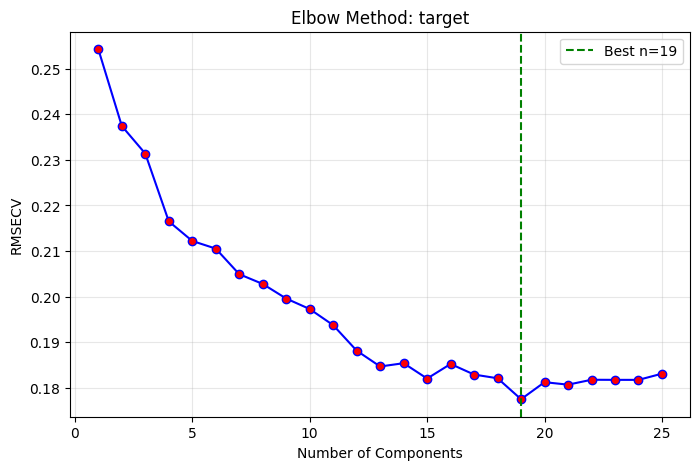

In [295]:
plt.figure(figsize=(8, 5))
plt.plot(components, rmse_cv, '-o', color='blue', markerfacecolor='red')
plt.axvline(best_n, color='green', linestyle='--', label=f'Best n={best_n}')
plt.title(f'Elbow Method: {"target"}')
plt.xlabel('Number of Components')
plt.ylabel('RMSECV')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
        

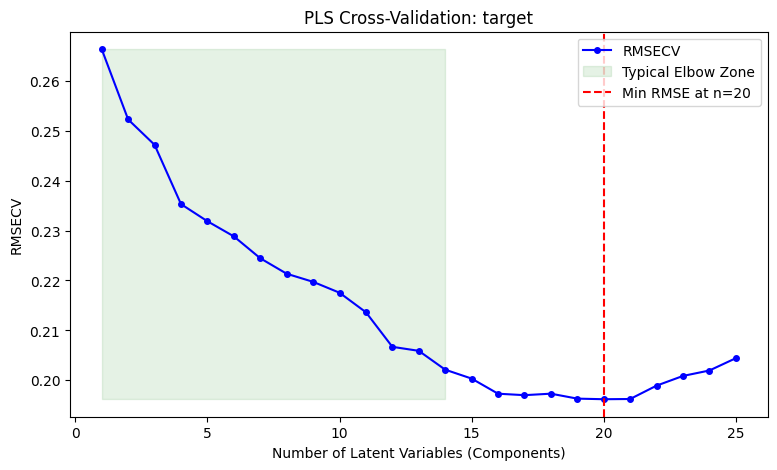

In [276]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

results = []

for n in test_range:
    # Use a Pipeline to ensure scaling is done INSIDE the CV folds
    # This prevents 'Data Leakage'
    pipe = Pipeline([
        ('scaler', StandardScaler()), 
        ('pls', PLSRegression(n_components=n))
    ])
    
    try:
        preds = cross_val_predict(pipe, X_pls_unique, y_values, cv=cv_strat, n_jobs=-1)
        rmse = np.sqrt(mean_squared_error(y_values, preds))
        results.append(rmse)
    except Exception as e:
        print(f"Failed at n={n}: {e}")
        results.append(np.inf)

rmse_cv = np.array(results)

# Refined Plotting: Add the '1-Standard Error' rule visual if you can
plt.figure(figsize=(9, 5))
plt.plot(test_range, rmse_cv, 'b-o', markersize=4, label='RMSECV')

# Highlight the elbow zone
plt.fill_between(test_range, rmse_cv.min(), rmse_cv.max(), 
                 where=(test_range < 15), color='green', alpha=0.1, label='Typical Elbow Zone')

plt.axvline(best_n, color='red', linestyle='--', label=f'Min RMSE at n={best_n}')
plt.title(f'PLS Cross-Validation: {"target"}')
plt.xlabel('Number of Latent Variables (Components)')
plt.ylabel('RMSECV')
plt.legend()
plt.show()

### sbm connection protocol

In [84]:
from dotenv import load_dotenv

# Load the .env file
load_dotenv()

# Access the variables using os.environ
my_username = os.getenv('SMB_USERNAME')
my_password = os.getenv('SMB_PASSWORD')
print(my_username)

davidb


In [ ]:
import smbclient
from smbclient.shutil import copyfile
import concurrent.futures
from smbclient import listdir, open_file

# # Network monitoring
# netstat -an | grep 445   # SMB port connections


# Method 1: Using smbclient.shutil
from smbclient import shutil
import smbclient
 
# Register session (required!)
smbclient.register_session(
    server='10.26.94.14',
    username=my_username,
    password=my_password
)

 


In [88]:
# Method 2: Direct share access
try:
    files = smbclient.listdir('//10.26.94.14/PhenomobileData/DavidDataForTest/Phenomobile')
    print("Files in share:", files[:10])  # First 10 files
except Exception as e:
    print(f"Error accessing share: {e}")

Files in share: ['Rehovot', 'BneiAtarot', 'NeweYaar', 'Gevim_Sesami']


In [99]:
import time
import os
import smbclient
import smbprotocol.connection
from smbclient import register_session
from dotenv import load_dotenv

def monitor_credits(username, password, server_ip='10.26.94.14'):
    register_session(server=server_ip, username=username, password=password)
    
    print(f"Monitoring credits for {server_ip}...")
    
    try:
        # 1. Force activity to ensure the connection is indexed
        folder1, folder2 = 'PhenomobileData', 'DavidDataForTest'
        path = f"\\\\{server_ip}\\{folder1}\\{folder2}"
        smbclient.listdir(path) 
        
        # 2. Find the connection pool
        # We look for any dictionary in the connection module that holds Connection objects
        target_conn = None
        
        # In most versions, it's either Connection.connections or a global _connections
        connections_pool = None
        if hasattr(smbprotocol.connection.Connection, 'connections'):
            connections_pool = smbprotocol.connection.Connection.connections
        elif hasattr(smbprotocol.connection, '_connections'):
            connections_pool = smbprotocol.connection._connections
            
        if connections_pool:
            for key, conn_obj in connections_pool.items():
                if server_ip in str(key):
                    target_conn = conn_obj
                    break
        
        if not target_conn:
            print(f"Could not find an active connection object for {server_ip}.")
            return

        # 3. Monitor the Sequence Window
        for i in range(10):
            # sequence_window.low is the available credits
            available = target_conn.sequence_window.low
            maximum = target_conn.max_credits
            
            percent = (available / maximum * 100) if maximum > 0 else 0
            print(f"[{i+1}] Credits: {available}/{maximum} ({percent:.1f}%)")
            
            if available < 10:
                print("⚠️  Warning: Server is heavily loaded!")
                
            time.sleep(1)
            
    except Exception as e:
        print(f"Monitor failed: {e}")

# Run
load_dotenv()
monitor_credits(os.getenv('SMB_USERNAME'), os.getenv('SMB_PASSWORD'))

Monitoring credits for 10.26.94.14...
Could not find an active connection object for 10.26.94.14.
